# IS 4487 Lab 13

## Learning Objectives
1. Select appropriate variables for a cluster analysis
2. Learn to fit and adjust a cluster analysis model based on similar customer behavioural patterns.
3. Interpret the output of the model

## Lab Tasks
1. Import and prepare data using the *SuperStore Retail Orders* dataset
2. Convert categorical variables to numbers or boolean
3. Fit a K-means model with 5 clusters
4. Display and analyze the results

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/Scripts/lab_13_retailer_cluster_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Superstore Data Dictionary

 ORDER VARIABLES:
 - Order ID
 - Order Date
 - Order Year Month - Year and month of the order
 - Order Type - Was the order completed at a store or online? (Retail, Online)
 - Quantity - Quantity ordered for the product

 CUSTOMER VARIABLES:
 - Customer Name
 - City
 - State Province
 - Email


PRODUCT VARIABLES:
 - Product Name
 - Product Line - Category of the product (i.e. Bikes Phones)
 - Product Price - Price in US Dollars
 - Product Status - Current status of the product (Active, Inactive)

## Load Libraries

➡️ Assignment Tasks
- Load any other necessary libraries, in addition to those below

In [56]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

## Import Data into Dataframe

➡️ Assignment Tasks
- Import data from the SuperStore retail dataset into a dataframe (in GitHub go to Labs > DataSets)
- Describe or profile the dataframe

In [34]:
df = pd.read_csv('https://github.com/Stan-Pugsley/is_4487_base/blob/main/Labs/DataSets/superstore_retail_orders.csv?raw=true')
df.describe()

,order_id,quantity,product_price
count,56043.000000,56004.000000,56043.000000
mean,61668.410578,3.348582,6198.309433
std,7508.142486,422.654112,35784.965255
min,45079.000000,1.000000,2.290000
25%,55644.500000,1.000000,7.950000
50%,61870.000000,1.000000,475.600000
75%,68097.000000,2.000000,914.620000
max,74147.000000,100000.000000,235481.000000


## Prepare Data
Note that K-Means requires that all variables be numbers or boolean.  No categorical variables are allowed.

➡️ Assignment Tasks
- Copy your dataframe into a new version, so that the original data is still available
- Create any needed variables, such as month of year and total_amount.  
- Filter out any incomplete orders
- Convert the OrderType and Product Line variables to multiple one-hot variables using OneHotEncoder (one variable for each value)
- Remove any variables that will be not be included (hint: only numeric variables are allowed)
- Remove any outliers that will cause a cluster to be created for the few records with the outlier value (pay close attention to dates, quantities and prices)

*Notes:*
- There is no need to split the data for cluster analysis.  Why is that the case?
- You should think carefully about which variables to include.  They should be independent and numeric, and have some behavioural aspect for customers.  A date, for example, cannot be used unless it is somehow converted to a number.  

In [46]:
#create new dataframe and do any number conversion
df_prepared = df.copy()
# Create new variables
df_prepared['order_date'] = pd.to_datetime(df_prepared['order_date'], errors='coerce')
df_prepared['order_month'] = df_prepared['order_date'].dt.month
df_prepared['total_amount'] = df_prepared['quantity'] * df_prepared['product_price']


In [47]:
#filter records with incomplete or invalid data
df_prepared = df_prepared.dropna(subset=['order_id'])

In [48]:
#one-hot encoding
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore') # sparse=False for easier handling
encoded_features = encoder.fit_transform(df_prepared[['order_type', 'product_line']])
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(['order_type', 'product_line']))
df_prepared = pd.concat([df_prepared, encoded_df], axis=1)
df_prepared = df_prepared.select_dtypes(include=['number'])

In [49]:
#remove outliers
Q1 = df_prepared['total_amount'].quantile(0.25)
Q3 = df_prepared['total_amount'].quantile(0.75)
IQR = Q3 - Q1
df_prepared = df_prepared[(df_prepared['total_amount'] >= Q1 - 1.5 * IQR) & (df_prepared['total_amount'] <= Q3 + 1.5 * IQR)]

In [50]:
#eliminate any variables that you don't want to use in the model (select your final variable set)
selected_features = ['total_amount', 'order_month',
                     'order_type_Online', 'order_type_Retail',
                     'product_line_Accessories', 'product_line_Bikes',
                     'product_line_Cameras' , 'product_line_Clothing',
                     'product_line_Electronics', 'product_line_Laptop',
                     'product_line_Mobile', 'product_line_OfficeProducts',
                     'product_line_Projector'
                     ]

df_cluster_data = df_prepared[selected_features]
df_cluster_data.head()

,total_amount,order_month,order_type_Online,order_type_Retail,product_line_Accessories,product_line_Bikes,product_line_Cameras,product_line_Clothing,product_line_Electronics,product_line_Laptop,product_line_Mobile,product_line_OfficeProducts,product_line_Projector
0,1949.97,7.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2599.96,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,649.99,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,649.99,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5,649.99,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Create Model

For more info on K-means in python, see: https://realpython.com/k-means-clustering-python/

➡️ Assignment Tasks
- Fit the K-means model using the Kmeans method
- Use 5 clusters

In [51]:
#create and fit model
#Feature Scaling
df_cluster_data = df_cluster_data.dropna()
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_cluster_data)
#Create and Fit Kmeans model
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(scaled_features)
#get cluser labels
cluster_labels = kmeans.labels_
#add cluster labels to df
df_cluster_data['cluster'] = cluster_labels


In [54]:
df_cluster_data.head()

,total_amount,order_month,order_type_Online,order_type_Retail,product_line_Accessories,product_line_Bikes,product_line_Cameras,product_line_Clothing,product_line_Electronics,product_line_Laptop,product_line_Mobile,product_line_OfficeProducts,product_line_Projector,cluster
0,1949.97,7.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4
1,2599.96,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
3,649.99,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
4,649.99,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
5,649.99,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1


## Analyze the Clusters

➡️ Assignment Tasks
- create at least two visualizations to show the clusters (try a Bar Chart, Pair Plot or Scatter Plot)
- Display the cluster and mean values for each of the variables

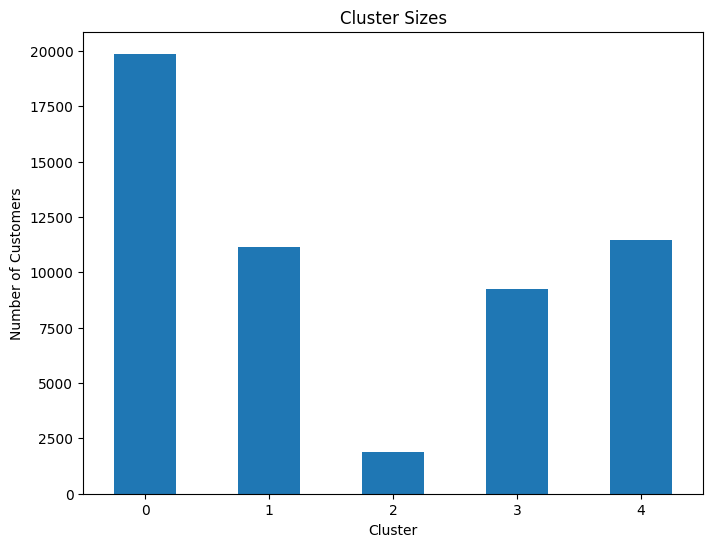

In [62]:
# visualization #1: Bar Chart of Cluster Sizes
plt.figure(figsize=(8, 6))
cluster_counts = df_cluster_data['cluster'].value_counts().sort_index()
cluster_counts.plot(kind='bar')
plt.title('Cluster Sizes')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

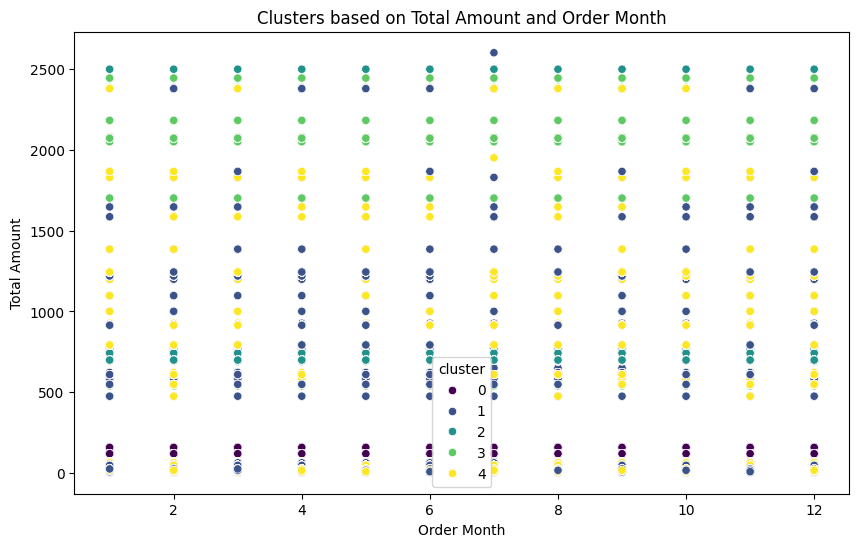

In [64]:
#visualization #2: Scatter Plot of Total Amount vs. Order Month
plt.figure(figsize=(10, 6))
sns.scatterplot(x='order_month', y='total_amount', hue='cluster', data=df_cluster_data, palette='viridis')
plt.title('Clusters based on Total Amount and Order Month')
plt.xlabel('Order Month')
plt.ylabel('Total Amount')
plt.show()

In [65]:
#cluster summary statistics
cluster_means = df_cluster_data.groupby('cluster').mean()
print(cluster_means)

         total_amount  order_month  order_type_Online  order_type_Retail  \
cluster                                                                    
0           17.455746     6.369163           0.498339           0.501661   
1          673.597188     6.362467           1.000000           0.000000   
2          778.776839     6.141032           0.399681           0.600319   
3         1816.453512     6.270376           0.427860           0.572140   
4          682.075927     6.386155           0.000000           1.000000   

         product_line_Accessories  product_line_Bikes  product_line_Cameras  \
cluster                                                                       
0                             1.0                 0.0                   0.0   
1                             0.0                 0.0                   0.0   
2                             0.0                 0.0                   1.0   
3                             0.0                 1.0                   